# Exploring Carbon dynamics from MODIS product in CDSE using openEO

This notebook demonstrates how easily MODIS data accessed and analysed in the Copernicus Data Space Ecosystem (CDSE) using openEO.

As a simple example, we explore vegetation and carbon dynamics over Antwerp. We use MODIS products such as NDVI, GPP and LAI to look at how vegetation changes over time and how this can be related to carbon uptake.

The focus is not on building a complex carbon analysis application, but on showing how an analysis can be done with openEO and executed in the CDSE cloud, without having to download and process the underlying satellite data locally.

Let us first connect to the openEO CDSE backend that offers several MODIS products. To explore more on about the data that are avilable in the CDSE STAC catalogue please visit [this notebook](./MODIS_data_using_openEO.ipynb).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import openeo

In [2]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [3]:
antwerp_polygon = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [4.04, 51.00],
                        [4.76, 51.00],
                        [4.76, 51.45],
                        [4.04, 51.45],
                        [4.04, 51.00]
                    ]
                ]
            },
            "properties": {}
        }
    ]
}

temporal_extent = ["2025-01-01", "2026-01-01"]

Since this notebooks uses several different MODIS products, it is convenient to wrap the STAC-loading logic in a small helper function that takes a collection ID and a list of bands, and returns the corresponding data cube for our area and time range.

In [4]:
def get_stac_cube(collection, bands):
    url = f"https://stac.dataspace.copernicus.eu/v1/collections/{collection}"
    stac_cube = connection.load_stac(url,
                                     temporal_extent=temporal_extent,
                                     spatial_extent=antwerp_polygon,
                                     bands=bands
                                     )
    return stac_cube

We start with NDVI product as an indicator of vegetation greenness and aggregate it spatially to obtain a time series over the area of interest.

In [5]:
collection_id1 = "modis-aqua-myd13a1"
bands1 = ["500m 16 days NDVI"]
ndvi_cube = get_stac_cube(collection_id1, bands1)

In [6]:
ndvi_ts = ndvi_cube.band("500m 16 days NDVI").aggregate_spatial(
    geometries=antwerp_polygon,
    reducer="mean"
)

In [7]:
ndvi_ts.execute_batch(title="NDVI timeseries in Antwerp", outputfile="carbon/ndvi_timeseries_antwerp.csv")

0:00:00 Job 'j-2609071621044237b12d5f1d315ecfce': send 'start'
0:00:08 Job 'j-2609071621044237b12d5f1d315ecfce': queued (progress 0%)
0:00:13 Job 'j-2609071621044237b12d5f1d315ecfce': queued (progress 0%)
0:00:20 Job 'j-2609071621044237b12d5f1d315ecfce': queued (progress 0%)
0:00:28 Job 'j-2609071621044237b12d5f1d315ecfce': queued (progress 0%)
0:00:38 Job 'j-2609071621044237b12d5f1d315ecfce': queued (progress 0%)
0:00:50 Job 'j-2609071621044237b12d5f1d315ecfce': queued (progress 0%)
0:01:06 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)
0:01:25 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)
0:01:49 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)
0:02:19 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)
0:02:57 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)
0:03:43 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)
0:04:42 Job 'j-2609071621044237b12d5f1d315ecfce': running (progress N/A)


<BatchJob job_id='j-2609071621044237b12d5f1d315ecfce'>

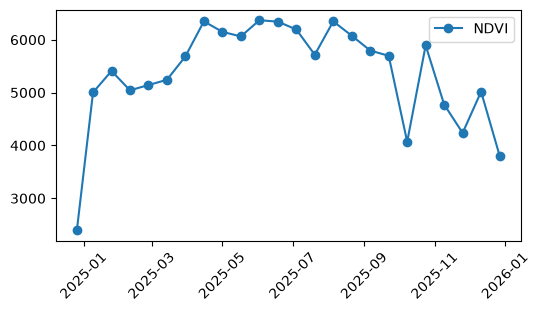

In [8]:
df = pd.read_csv("carbon/ndvi_timeseries_antwerp.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.sort_index()
plt.figure(figsize=(6, 3))
plt.plot(df.index, df["band_unnamed"], label="NDVI",marker="o")
plt.xticks(rotation=45)
plt.legend()
plt.show()

The resulting time series shows the expected seasonal variation in vegetation activity, with higher values during the growing season and lower values towards winter.

We then retrieve GPP (Gross Primary Productivity) and use it together with LAI (Leaf Area Index) to derive a simple carbon uptake efficiency indicator.

In [9]:
collection_id3 = "modis-aqua-myd17a2h"
bands3 = ["Gpp_500m"]
gpp = get_stac_cube(collection_id3, bands3)

Let us now access the LAI product, available as 8-day composites. We need LAI specifically for the carbon uptake efficiency calculation: GPP / LAI. 

In [10]:
collection_id2 = "modis-aqua-myd15a2h"
bands2 = ["Lai_500m"]
lai_fpar = get_stac_cube(collection_id2, bands2)

Note that `gpp` and `lai_fpar` are still two separate datacubes at this point, so dividing them directly doesn't align their bands or dimensions properly, so this result isn't reliable yet. The correct approach is to merge the two cubes first with `merge_cubes`, so their dimensions are aligned, and only then select and divide the specific bands we need to get carbon uptake efficiency.

In [11]:
merged_cube = gpp.merge_cubes(lai_fpar)
carbon_uptake = merged_cube.band("Gpp_500m")/ merged_cube.band("Lai_500m")

In [ ]:
carbon_uptake.execute_batch(title="Carbon Uptake", outputfile="carbon/carbon_uptake_antwerp.nc")

0:00:00 Job 'j-2609071720054af8b861027e4d566e97': send 'start'
0:00:11 Job 'j-2609071720054af8b861027e4d566e97': created (progress 0%)
0:00:17 Job 'j-2609071720054af8b861027e4d566e97': queued (progress 0%)
0:00:23 Job 'j-2609071720054af8b861027e4d566e97': queued (progress 0%)
0:00:31 Job 'j-2609071720054af8b861027e4d566e97': queued (progress 0%)
0:00:41 Job 'j-2609071720054af8b861027e4d566e97': queued (progress 0%)
0:00:53 Job 'j-2609071720054af8b861027e4d566e97': queued (progress 0%)
0:01:09 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)
0:01:28 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)
0:01:52 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)
0:02:23 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)
0:03:00 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)
0:03:47 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)
0:04:45 Job 'j-2609071720054af8b861027e4d566e97': running (progress N/A)

In [ ]:
carbon_uptake_ds = xr.open_dataset("carbon/carbon_uptake_antwerp.nc")
carbon_uptake_ds

<xarray.Dataset> Size: 5GB
Dimensions:  (t: 46, x: 5124, y: 5101)
Coordinates:
  * t        (t) datetime64[ns] 368B 2025-01-01 2025-01-09 ... 2025-12-27
  * x        (x) float64 41kB 5.723e+05 5.723e+05 ... 6.235e+05 6.235e+05
  * y        (y) float64 41kB 5.701e+06 5.701e+06 ... 5.65e+06 5.65e+06
Data variables:
    crs      |S1 1B ...
    var      (t, y, x) float32 5GB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.73.0a16.dev2...
    description:  
    title:

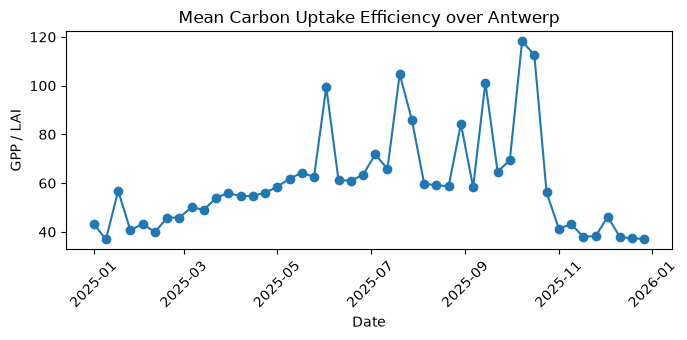

In [ ]:
# plot mean carbon uptake over the AOI
carbon_uptake_var = next(
    data_array
    for _, data_array in carbon_uptake_ds.data_vars.items()
    if {"x", "y"}.issubset(data_array.dims)
    and data_array.dtype.kind in "fiu"
    and "t" in data_array.dims
)
mean_carbon_uptake = carbon_uptake_var.mean(dim=["x", "y"], skipna=True)

plt.figure(figsize=(7, 3.5))
plt.plot(
    mean_carbon_uptake.t,
    mean_carbon_uptake,
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("GPP / LAI")
plt.title("Mean Carbon Uptake Efficiency over Antwerp")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The results provide a first look at the seasonal dynamics of vegetation and carbon uptake over the study area. NDVI increases through spring, remains relatively high during summer, and decreases again towards autumn and winter. The derived carbon uptake indicator follows a similar seasonal pattern, with generally higher values during the growing season and lower values towards the end of the year.
This is a simple example, but it illustrates how MODIS products can be combined to move from satellite observations to a meaningful environmental indicator.

In [ ]:
print("completed successfully")